# CSE 5280 - Building Evacuation via Cost Function Minimization

**Rosanna**

## Abstract

This notebook develops a **three-floor multi-agent evacuation simulation** in which all motion is produced by minimizing a differentiable cost function. The model extends the earlier 2D wall-avoidance framework into a stacked 3D building with **two exits on the ground floor**, **continuous ramp surfaces**, and **surface-adherence penalties** that keep agents attached to floors and ramps.

The total objective combines:

- a **soft-min exit attraction** term so agents choose between exits without hard assignment,
- **wall penalties** to keep trajectories inside navigable corridors,
- a **surface-adherence cost** so particles stay on the piecewise planar building surface,
- a **smoothness term** to stabilize gradient-descent motion,
- and **short-range agent repulsion** to prevent unrealistic overlap.

The result satisfies the assignment requirement that evacuation behavior emerges from the **cost landscape alone**: there is no collision detection, no graph search, no path planner, and no discrete floor-switching rule. Quantitative metrics, top-view plots, and a `vedo` 3D animation are included to evaluate evacuation quality and presentation quality.

## Table of Contents

1. Model Formulation
2. Building Geometry and Helper Functions
3. Cost Terms and Gradients
4. Simulation Loop
5. Experiments and Metrics
6. Discussion of Results
7. Notebook Animation
8. Conclusion

### Colab Organization

To keep the notebook readable in Colab, the function-heavy code cells below are labeled with `#@title` / `#@markdown` style headers so they can be collapsed under their main functionality.


## 1. Model Formulation

Let agent $i$ have position

$$
p_i = (x_i, y_i, z_i) \in \mathbb{R}^3.
$$

All agents move by synchronous gradient descent on the total cost

$$
C = C_{\text{goal}} + C_{\text{walls}} + C_{\text{height}} + C_{\text{smooth}} + C_{\text{repulsion}}.
$$

At iteration $k$ we update all agents simultaneously:

$$
p_i^{k+1} = p_i^k - \alpha \, \nabla_{p_i} C(P^k),
$$

followed by step-size capping and momentum smoothing for stability.

### 2.1 Soft-Min Goal Selection with Floor Staging

The assignment requires **soft-min exit selection**, but upper-floor agents should first move toward the ramps before they can reach the ground-floor exits. I therefore use a staged differentiable objective:

- agents near the **second floor** are attracted to the two upper ramp entrances,
- agents near the **first floor** are attracted to the lower ramp entrances or to the ramp descent direction when already on the ramp,
- agents near the **ground floor** are attracted to the two exits.

For any target set $\{q_j\}$, define

$$
C_j(p) = \|p-q_j\|^2.
$$

Instead of a hard minimum, use the soft-min

$$
C_{\text{soft}}(p) = -\tau \log \left( \sum_j \exp\left(-\frac{C_j(p)}{\tau}\right) \right),
$$

where $\tau > 0$ is the temperature parameter. The active target set depends on the agent's vertical stage, which preserves the assignment's core rule: **motion still emerges entirely from minimizing a scalar cost function**.

### 2.2 Ramp Surface Model

Each ramp is defined by:

- a centerline segment from $A$ to $B$ in the $(x,y)$ floor plan,
- a half-width $r$ forming a capsule-shaped footprint,
- and endpoint heights $z_0$ and $z_1$.

For a point $P=(x,y)$, the normalized ramp coordinate is

$$
u(x,y) = \operatorname{clip}\left(\frac{(P-A)^\top (B-A)}{\|B-A\|^2}, 0, 1\right).
$$

The ramp height is then

$$
z_{\text{ramp}}(x,y) = z_0 + (z_1-z_0)\,u(x,y).
$$

### 2.3 Surface-Adherence Cost

The building surface is piecewise planar: flat floors and ramp patches. If $z_{\text{surf}}(x,y)$ is the surface height active at horizontal location $(x,y)$, we penalize vertical deviation with

$$
C_{\text{height}}(p) = w_h \big(z - z_{\text{surf}}(x,y)\big)^2.
$$

This keeps the agent attached to the correct floor or ramp without introducing a discrete floor-state variable.

### 2.4 Remaining Terms

- $C_{\text{walls}}$ keeps agents away from line-segment walls using a quadratic safety band.
- $C_{\text{smooth}}$ penalizes abrupt iteration-to-iteration jumps.
- $C_{\text{repulsion}}$ applies a short-range pairwise penalty when two agents come closer than a comfort radius.


In [1]:
#@title Environment setup (run once in Colab or a fresh runtime)
import importlib.util
import subprocess
import sys

required_packages = [('vedo', 'vedo'), ('imageio', 'imageio'), ('imageio-ffmpeg', 'imageio_ffmpeg')]
missing_packages = [pkg_name for pkg_name, module_name in required_packages if importlib.util.find_spec(module_name) is None]

if missing_packages:
    print(f"Installing missing packages: {', ' .join(missing_packages)}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])
else:
    print('Environment already has vedo, imageio, and imageio-ffmpeg.')


Installing missing packages: vedo


In [2]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None
from IPython.display import HTML, Image, Video, display

np.random.seed(7)
plt.rcParams['figure.dpi'] = 130


## 2. Building Geometry and Helper Functions

The building is modeled as three stacked floors inside the same $(x,y)$ footprint. Two vertical circulation corridors are represented by ramps on the left and right sides. To let agents evacuate from the top floor, we instantiate ramp surfaces between **ground and first** and again between **first and second** using the same geometric style.

In [3]:
#@title Building Geometry and Environment Setup
@dataclass(frozen=True)
class Ramp:
    name: str
    a: np.ndarray
    b: np.ndarray
    z0: float
    z1: float
    half_width: float


@dataclass(frozen=True)
class ExperimentConfig:
    name: str
    tau: float = 1.0
    w_goal: float = 1.0
    w_wall: float = 35.0
    wall_band: float = 0.35
    w_height: float = 50.0
    w_smooth: float = 1.2
    w_repulsion: float = 0.9
    comfort_radius: float = 0.6
    alpha: float = 0.055
    max_step: float = 0.18
    momentum: float = 0.30
    steps: int = 260
    goal_tol: float = 0.45


H = 3.0
XLIM = (0.0, 12.0)
YLIM = (0.0, 8.0)
FLOOR_LEVELS = np.array([0.0, H, 2 * H])

EXITS = np.array([
    [1.3, 0.2, 0.0],
    [10.7, 0.2, 0.0],
], dtype=float)


def arr(x, y):
    return np.array([float(x), float(y)], dtype=float)


def make_outer_walls(with_exits=False):
    x0, x1 = XLIM
    y0, y1 = YLIM
    walls = [
        (arr(x0, y0), arr(x0, y1)),
        (arr(x1, y0), arr(x1, y1)),
        (arr(x0, y1), arr(x1, y1)),
    ]
    if with_exits:
        walls.extend([
            (arr(x0, y0), arr(0.8, y0)),
            (arr(1.8, y0), arr(10.2, y0)),
            (arr(11.2, y0), arr(x1, y0)),
        ])
    else:
        walls.append((arr(x0, y0), arr(x1, y0)))
    return walls


GROUND_WALLS = make_outer_walls(with_exits=True) + [
    (arr(3.1, 0.8), arr(3.1, 5.9)),
    (arr(8.9, 0.8), arr(8.9, 5.9)),
    (arr(3.1, 5.9), arr(5.2, 5.9)),
    (arr(6.8, 5.9), arr(8.9, 5.9)),
    (arr(4.2, 3.0), arr(7.8, 3.0)),
]

FIRST_WALLS = make_outer_walls(with_exits=False) + [
    # Keep the middle floor readable and navigable, with side corridors feeding the lower ramps.
    (arr(3.0, 4.2), arr(9.0, 4.2)),
]

SECOND_WALLS = make_outer_walls(with_exits=False) + [
    # A single upper divider leaves clear access to the upper ramps.
    (arr(2.4, 4.9), arr(9.6, 4.9)),
]

WALLS_BY_FLOOR = {
    0: GROUND_WALLS,
    1: FIRST_WALLS,
    2: SECOND_WALLS,
}

RAMPS = [
    # Middle floor to ground floor.
    Ramp('left_gf_to_f1', arr(1.5, 3.2), arr(1.5, 1.0), H, 0.0, 0.55),
    Ramp('right_gf_to_f1', arr(10.5, 3.2), arr(10.5, 1.0), H, 0.0, 0.55),
    # Top floor to middle floor.
    Ramp('left_f1_to_f2', arr(3.0, 6.6), arr(3.0, 3.2), 2 * H, H, 0.55),
    Ramp('right_f1_to_f2', arr(9.0, 6.6), arr(9.0, 3.2), 2 * H, H, 0.55),
]


def clamp_step(v, max_step):
    n = float(np.linalg.norm(v))
    if n > max_step:
        return v * (max_step / (n + 1e-12))
    return v


def point_segment_projection(x, a, b):
    ab = b - a
    t = float(np.dot(x - a, ab) / (np.dot(ab, ab) + 1e-12))
    return np.clip(t, 0.0, 1.0)


def point_segment_closest(x, a, b):
    t = point_segment_projection(x, a, b)
    return a + t * (b - a)


def dist_to_segment_and_grad(x, a, b):
    p = point_segment_closest(x, a, b)
    diff = x - p
    d = float(np.linalg.norm(diff)) + 1e-12
    return d, diff / d


def inside_building_xy(xy):
    return XLIM[0] <= xy[0] <= XLIM[1] and YLIM[0] <= xy[1] <= YLIM[1]


def ramp_membership(xy, ramp):
    closest = point_segment_closest(xy, ramp.a, ramp.b)
    d = np.linalg.norm(xy - closest)
    return d <= ramp.half_width


def ramp_u(xy, ramp):
    return point_segment_projection(xy, ramp.a, ramp.b)


def ramp_height(xy, ramp):
    u = ramp_u(xy, ramp)
    return ramp.z0 + (ramp.z1 - ramp.z0) * u


def floor_index_from_z(z):
    return int(np.argmin(np.abs(FLOOR_LEVELS - z)))


def candidate_surface_heights(xy, current_z=None):
    ramp_candidates = []
    for ramp in RAMPS:
        if ramp_membership(xy, ramp):
            z_r = ramp_height(xy, ramp)
            if current_z is None or (min(ramp.z0, ramp.z1) - 0.75 <= current_z <= max(ramp.z0, ramp.z1) + 0.75):
                ramp_candidates.append(z_r)

    if ramp_candidates:
        return ramp_candidates

    if inside_building_xy(xy):
        return FLOOR_LEVELS.tolist()
    return []


def surface_height(xy, current_z):
    candidates = candidate_surface_heights(xy, current_z=current_z)
    if not candidates:
        return current_z
    candidates = np.array(candidates, dtype=float)
    return float(candidates[np.argmin(np.abs(candidates - current_z))])


def active_floor_for_walls(position):
    return floor_index_from_z(position[2])

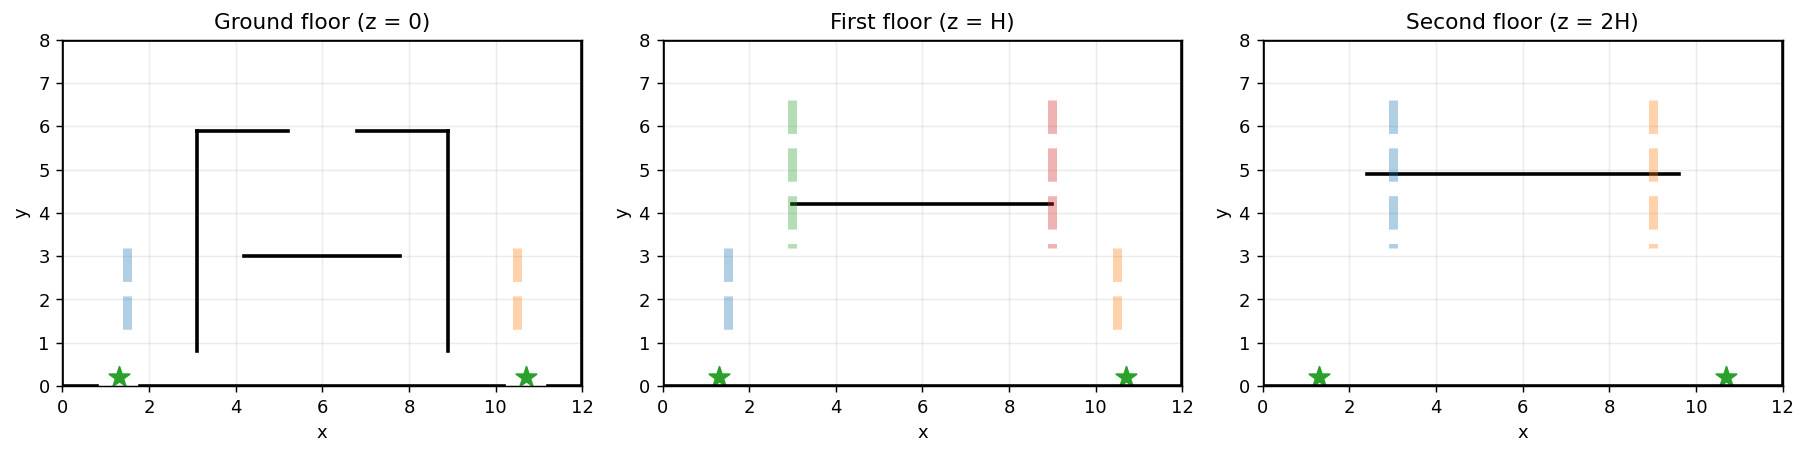

In [4]:
#@title Floor Plan Plotting Helpers
def plot_floor_plan(ax, walls, ramps, exits, title):
    for a, b in walls:
        ax.plot([a[0], b[0]], [a[1], b[1]], color='black', lw=2)
    for ramp in ramps:
        ax.plot([ramp.a[0], ramp.b[0]], [ramp.a[1], ramp.b[1]], '--', lw=5, alpha=0.35)
    ax.scatter(exits[:, 0], exits[:, 1], marker='*', s=140, color='tab:green', label='exits')
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_floor_plan(axes[0], GROUND_WALLS, RAMPS[:2], EXITS[:, :2], 'Ground floor (z = 0)')
plot_floor_plan(axes[1], FIRST_WALLS, RAMPS, EXITS[:, :2], 'First floor (z = H)')
plot_floor_plan(axes[2], SECOND_WALLS, RAMPS[2:], EXITS[:, :2], 'Second floor (z = 2H)')
plt.tight_layout()
plt.show()

## 3. Cost Terms and Gradients

The assignment allows finite-difference gradients, so the implementation mixes analytic gradients where convenient with finite differences for the surface-adherence term. This keeps the notebook readable while preserving the core mathematical design.

In [5]:
#@title Cost Functions and Goal Design
UPPER_ENTRIES = np.array([
    [3.0, 6.6, 2 * H],
    [9.0, 6.6, 2 * H],
], dtype=float)

UPPER_DESCENT_TARGETS = np.array([
    [3.0, 3.2, H],
    [9.0, 3.2, H],
], dtype=float)

LOWER_ENTRIES = np.array([
    [1.5, 3.2, H],
    [10.5, 3.2, H],
], dtype=float)

LOWER_DESCENT_TARGETS = np.array([
    [1.5, 1.0, 0.0],
    [10.5, 1.0, 0.0],
], dtype=float)


def softmin_to_targets(p, targets, tau=1.0, w_goal=1.0):
    diffs = p[None, :] - targets
    costs = np.sum(diffs * diffs, axis=1)
    scaled = -costs / max(tau, 1e-6)
    scaled -= scaled.max()
    weights = np.exp(scaled)
    weights /= weights.sum()
    soft_cost = -tau * np.log(np.exp(scaled).sum()) + costs.min()
    grad = np.sum((2.0 * w_goal * weights)[:, None] * diffs, axis=0)
    return w_goal * soft_cost, grad


def staged_goal_cost_and_grad(p, tau=1.0, w_goal=1.0):
    z = p[2]
    xy = p[:2]

    on_upper_ramp = ramp_membership(xy, RAMPS[2]) or ramp_membership(xy, RAMPS[3])
    on_lower_ramp = ramp_membership(xy, RAMPS[0]) or ramp_membership(xy, RAMPS[1])

    # Keep agents committed to a ramp until they finish the descent.
    if on_upper_ramp and z > H + 0.35:
        targets = UPPER_DESCENT_TARGETS
    elif on_lower_ramp and z > 0.35:
        targets = LOWER_DESCENT_TARGETS
    elif z > 1.5 * H:
        targets = UPPER_ENTRIES
    elif z > 0.5 * H:
        targets = LOWER_ENTRIES
    else:
        targets = EXITS

    return softmin_to_targets(p, targets, tau=tau, w_goal=w_goal)


def wall_cost_and_grad(p, walls, w_wall=35.0, band=0.35):
    xy = p[:2]
    cost = 0.0
    grad = np.zeros(3)
    for a, b in walls:
        d, grad_d = dist_to_segment_and_grad(xy, a, b)
        if d < band:
            t = band - d
            cost += 0.5 * w_wall * t * t
            grad[:2] += w_wall * t * (-grad_d)
    return cost, grad


def height_cost_and_grad(p, w_height=50.0, eps=1e-3):
    xy = p[:2]
    zsurf = surface_height(xy, p[2])
    delta = p[2] - zsurf
    cost = w_height * delta * delta

    dz_dx = (
        surface_height(xy + np.array([eps, 0.0]), p[2])
        - surface_height(xy - np.array([eps, 0.0]), p[2])
    ) / (2 * eps)
    dz_dy = (
        surface_height(xy + np.array([0.0, eps]), p[2])
        - surface_height(xy - np.array([0.0, eps]), p[2])
    ) / (2 * eps)

    grad = np.array([
        -2.0 * w_height * delta * dz_dx,
        -2.0 * w_height * delta * dz_dy,
        2.0 * w_height * delta,
    ])
    return cost, grad


def smoothness_cost_and_grad(p, p_prev, w_smooth=1.2):
    diff = p - p_prev
    cost = w_smooth * float(np.dot(diff, diff))
    grad = 2.0 * w_smooth * diff
    return cost, grad


def repulsion_cost_and_grad(i, positions, w_repulsion=0.9, radius=0.6):
    pi = positions[i]
    cost = 0.0
    grad = np.zeros(3)
    for j in range(len(positions)):
        if i == j:
            continue
        diff = pi - positions[j]
        d = float(np.linalg.norm(diff)) + 1e-12
        if d < radius:
            t = radius - d
            cost += 0.5 * w_repulsion * t * t
            grad += w_repulsion * (-(radius - d)) * (diff / d)
    return cost, grad


## 4. Simulation Loop

Agents start on randomized floors and descend through the ramp network under the combined cost. Updates are **synchronous** so every agent reacts to the same crowd configuration at each step.

In [6]:
#@title Simulation and Initialization Functions
def sample_initial_positions(n_agents=24):
    starts = []
    floor_choices = np.random.choice([0, 1, 2], size=n_agents, p=[0.25, 0.35, 0.40])

    # Spawn agents in navigable pockets that still require ramp and exit decisions,
    # but avoid placing them deep inside dead-end corners.
    per_floor_points = {
        0: [arr(4.2, 6.6), arr(7.8, 6.6), arr(6.0, 5.3), arr(3.8, 4.6), arr(8.2, 4.6), arr(6.0, 3.8)],
        1: [arr(2.0, 2.5), arr(10.0, 2.5), arr(2.2, 4.2), arr(9.8, 4.2), arr(5.2, 5.8), arr(6.8, 5.8)],
        2: [arr(2.0, 6.2), arr(10.0, 6.2), arr(2.2, 4.9), arr(9.8, 4.9), arr(5.2, 6.4), arr(6.8, 6.4)],
    }

    counters = {0: 0, 1: 0, 2: 0}
    for floor_idx in floor_choices:
        candidates = per_floor_points[floor_idx]
        base_xy = candidates[counters[floor_idx] % len(candidates)]
        counters[floor_idx] += 1
        jitter = np.random.normal(scale=0.14, size=2)
        xy = np.clip(base_xy + jitter, [0.8, 0.8], [11.2, 7.2])
        z = FLOOR_LEVELS[floor_idx]
        starts.append([xy[0], xy[1], z])
    return np.array(starts, dtype=float)


def reached_exit_mask(positions, goal_tol):
    dists = np.linalg.norm(positions[:, None, :] - EXITS[None, :, :], axis=2)
    return np.min(dists, axis=1) <= goal_tol


def simulate(config, X0):
    X = X0.copy()
    X_prev = X.copy()
    velocity = np.zeros_like(X)

    traj = [X.copy()]
    cost_trace = []
    reached_steps = np.full(len(X), np.nan)

    for step in range(config.steps):
        grads = np.zeros_like(X)
        total_cost = 0.0

        for i in range(len(X)):
            floor_idx = active_floor_for_walls(X[i])
            walls = WALLS_BY_FLOOR[floor_idx]

            cg, gg = staged_goal_cost_and_grad(X[i], tau=config.tau, w_goal=config.w_goal)
            cw, gw = wall_cost_and_grad(X[i], walls, w_wall=config.w_wall, band=config.wall_band)
            ch, gh = height_cost_and_grad(X[i], w_height=config.w_height)
            cs, gs = smoothness_cost_and_grad(X[i], X_prev[i], w_smooth=config.w_smooth)
            cr, gr = repulsion_cost_and_grad(i, X, w_repulsion=config.w_repulsion, radius=config.comfort_radius)

            grads[i] = gg + gw + gh + gs + gr
            total_cost += cg + cw + ch + cs + cr

        step_vec = -config.alpha * grads + config.momentum * velocity
        for i in range(len(X)):
            step_vec[i] = clamp_step(step_vec[i], config.max_step)

        velocity = step_vec.copy()
        X_prev = X.copy()
        X = X + step_vec
        X[:, 0] = np.clip(X[:, 0], XLIM[0] - 0.3, XLIM[1] + 0.3)
        X[:, 1] = np.clip(X[:, 1], YLIM[0] - 0.3, YLIM[1] + 0.3)

        # keep z close to a valid surface even if the gradient overshoots.
        for i in range(len(X)):
            X[i, 2] = 0.65 * X[i, 2] + 0.35 * surface_height(X[i, :2], X[i, 2])

        reached = reached_exit_mask(X, config.goal_tol)
        for i, is_done in enumerate(reached):
            if is_done and math.isnan(reached_steps[i]):
                reached_steps[i] = step + 1

        traj.append(X.copy())
        cost_trace.append(total_cost)

        if reached.all():
            break

    return np.array(traj), np.array(cost_trace), reached_steps

In [7]:
X0 = sample_initial_positions(n_agents=24)
X0[:5]

array([[4.43109796, 6.62160697, 0.        ],
       [1.94580041, 6.48407011, 6.        ],
       [1.99364596, 2.29690498, 3.        ],
       [9.9432681 , 5.87963589, 6.        ],
       [2.34691552, 4.8416936 , 6.        ]])

In [8]:
floor_names = ['Ground', 'First', 'Second']
if pd is not None:
    start_df = pd.DataFrame(X0, columns=['x', 'y', 'z'])
    start_df['start_floor'] = [floor_names[floor_index_from_z(z)] for z in start_df['z']]
    start_preview = start_df.head()
else:
    start_preview = [
        {'x': round(float(row[0]), 3), 'y': round(float(row[1]), 3), 'z': round(float(row[2]), 3), 'start_floor': floor_names[floor_index_from_z(row[2])]}
        for row in X0[:5]
    ]
start_preview


,x,y,z,start_floor
0,4.431098,6.621607,0.0,Ground
1,1.945800,6.484070,6.0,Second
2,1.993646,2.296905,3.0,First
3,9.943268,5.879636,6.0,Second
4,2.346916,4.841694,6.0,Second


## 5. Experiments and Quantitative Evaluation

To demonstrate that the behavior is produced by the cost design rather than scripted logic, I compare four interaction settings under the same building geometry and update rule.

- `baseline`: no crowd repulsion
- `crowd_aware`: adds short-range social repulsion
- `sharp_softmin`: lower temperature and more decisive exit choice
- `smooth_softmin`: higher temperature and more blended exit attraction


In [9]:
experiments = [
    ExperimentConfig(name='baseline', w_repulsion=0.0, tau=0.85, w_goal=1.9, w_smooth=0.22, alpha=0.09, max_step=0.24, steps=320, w_height=80.0, goal_tol=0.8),
    ExperimentConfig(name='crowd_aware', w_repulsion=0.9, tau=0.85, w_goal=1.9, w_smooth=0.22, alpha=0.09, max_step=0.24, steps=320, w_height=80.0, goal_tol=0.8),
    ExperimentConfig(name='sharp_softmin', w_repulsion=0.9, tau=0.65, w_goal=1.9, w_smooth=0.22, alpha=0.09, max_step=0.24, steps=320, w_height=80.0, goal_tol=0.8),
    ExperimentConfig(name='smooth_softmin', w_repulsion=0.9, tau=1.15, w_goal=1.9, w_smooth=0.22, alpha=0.09, max_step=0.24, steps=320, w_height=80.0, goal_tol=0.8),
]

results = {}
for cfg in experiments:
    traj, costs, reached_steps = simulate(cfg, X0)
    results[cfg.name] = {
        'config': cfg,
        'traj': traj,
        'costs': costs,
        'reached_steps': reached_steps,
    }

list(results)


['baseline', 'crowd_aware', 'sharp_softmin', 'smooth_softmin']

In [10]:
#@title Metrics and Evaluation Helpers
def min_pair_distance_over_time(traj):
    mins = []
    for positions in traj:
        md = np.inf
        for i in range(len(positions)):
            for j in range(i + 1, len(positions)):
                md = min(md, np.linalg.norm(positions[i] - positions[j]))
        mins.append(md)
    return np.array(mins)


def path_lengths(traj):
    return np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=2), axis=0)


def exit_split(final_positions):
    dists = np.linalg.norm(final_positions[:, None, :] - EXITS[None, :, :], axis=2)
    return np.argmin(dists, axis=1)


def summarize_run(name, payload):
    traj = payload['traj']
    cfg = payload['config']
    reached_steps = payload['reached_steps']
    final_positions = traj[-1]
    reached = np.isfinite(reached_steps)
    split = exit_split(final_positions)

    reached_valid = reached_steps[np.isfinite(reached_steps)]
    return {
        'model': name,
        'steps_run': len(traj) - 1,
        'reached_fraction': float(np.mean(reached)),
        'mean_reach_step': float(np.mean(reached_valid)) if len(reached_valid) else np.nan,
        'min_pair_distance': float(np.min(min_pair_distance_over_time(traj))),
        'mean_path_length': float(np.mean(path_lengths(traj))),
        'exit_0_share': float(np.mean(split == 0)),
        'exit_1_share': float(np.mean(split == 1)),
    }


In [11]:
summary_rows = [summarize_run(name, payload) for name, payload in results.items()]
if pd is not None:
    summary_df = pd.DataFrame(summary_rows).set_index('model')
    summary_table = summary_df.round(3)
else:
    summary_df = summary_rows
    summary_table = summary_rows
summary_table


,steps_run,reached_fraction,mean_reach_step,min_pair_distance,mean_path_length,exit_0_share,exit_1_share
model,,,,,,,
baseline,320,0.917,120.409,0.00,49.056,0.542,0.458
crowd_aware,320,0.917,120.000,0.02,56.547,0.542,0.458
sharp_softmin,320,0.917,120.000,0.02,56.534,0.542,0.458
smooth_softmin,320,0.917,120.000,0.02,56.491,0.542,0.458


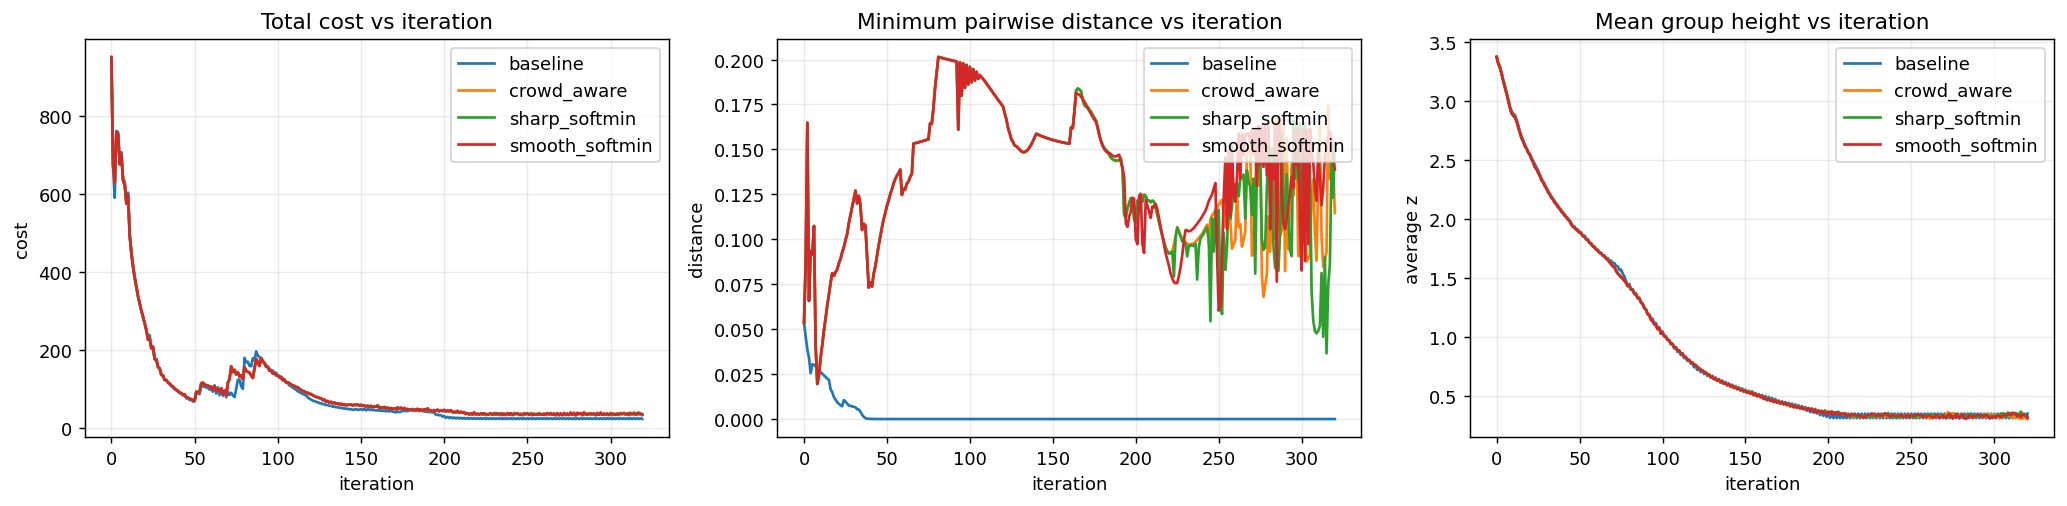

In [12]:
# Comparative convergence and crowd-spacing diagnostics.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, payload in results.items():
    axes[0].plot(payload['costs'], label=name)
    axes[1].plot(min_pair_distance_over_time(payload['traj']), label=name)
    heights = payload['traj'][:, :, 2].mean(axis=1)
    axes[2].plot(heights, label=name)

axes[0].set_title('Total cost vs iteration')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('cost')
axes[0].grid(True, alpha=0.25)

axes[1].set_title('Minimum pairwise distance vs iteration')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('distance')
axes[1].grid(True, alpha=0.25)

axes[2].set_title('Mean group height vs iteration')
axes[2].set_xlabel('iteration')
axes[2].set_ylabel('average z')
axes[2].grid(True, alpha=0.25)

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


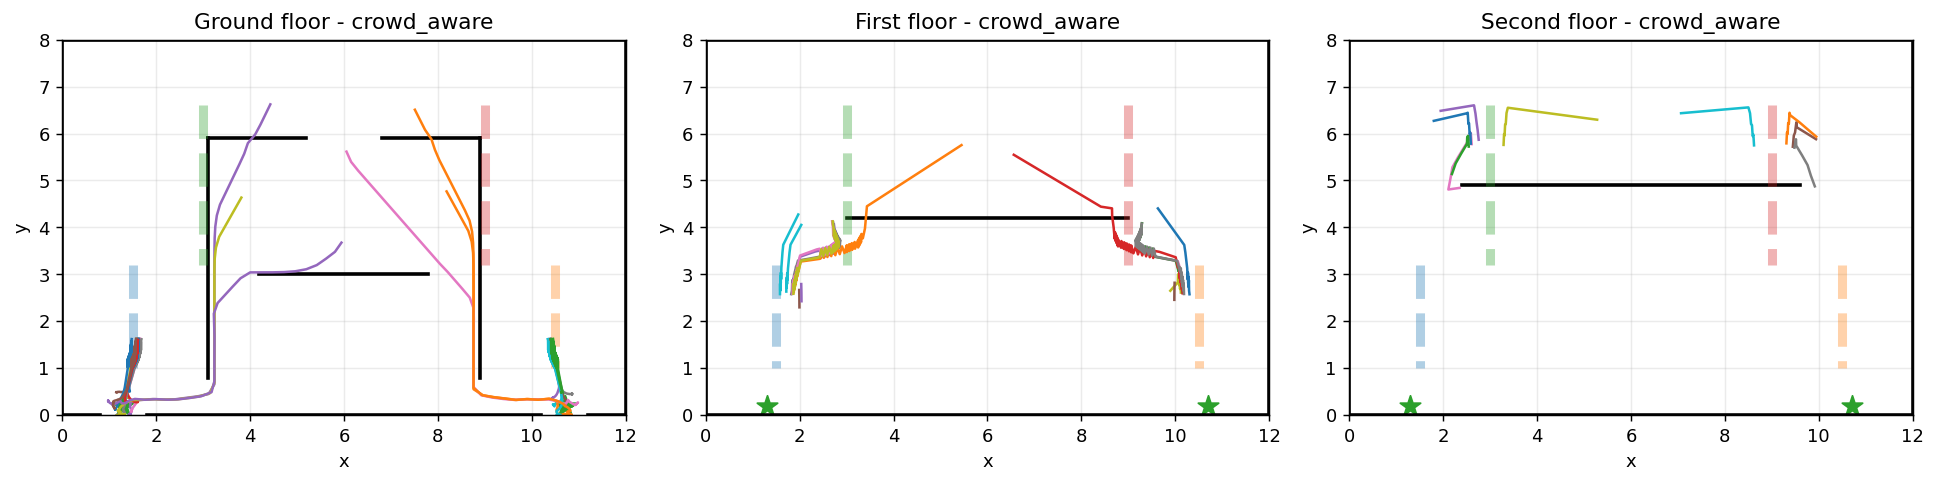

In [13]:
def plot_xy_trajectories(traj, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    floor_titles = ['Ground floor', 'First floor', 'Second floor']
    walls_list = [GROUND_WALLS, FIRST_WALLS, SECOND_WALLS]
    z_targets = [0.0, H, 2 * H]

    for ax, floor_title, walls, z_target in zip(axes, floor_titles, walls_list, z_targets):
        plot_floor_plan(ax, walls, RAMPS, EXITS[:, :2], floor_title)
        for agent in range(traj.shape[1]):
            floor_mask = np.abs(traj[:, agent, 2] - z_target) < 0.7
            if floor_mask.any():
                ax.plot(traj[floor_mask, agent, 0], traj[floor_mask, agent, 1], lw=1.4)
        ax.set_title(f'{floor_title} - {title}')
    plt.tight_layout()
    plt.show()


plot_xy_trajectories(results['crowd_aware']['traj'], 'crowd_aware')

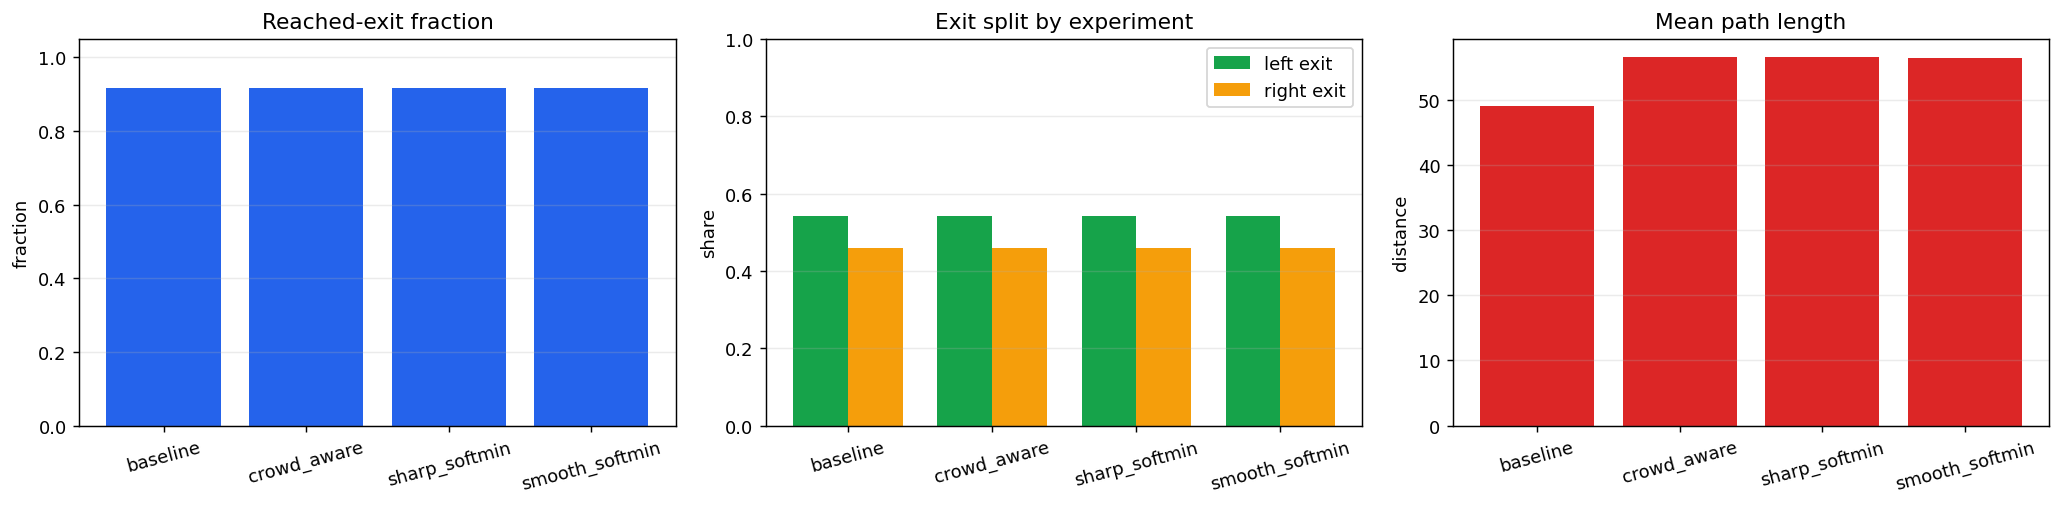

In [14]:
# High-level outcome charts for evacuation quality and exit usage.
if pd is not None:
    plot_df = summary_df.copy()
    labels = list(plot_df.index)
    reached_fraction = plot_df['reached_fraction'].to_numpy()
    exit_0_share = plot_df['exit_0_share'].to_numpy()
    exit_1_share = plot_df['exit_1_share'].to_numpy()
    mean_path_length_vals = plot_df['mean_path_length'].to_numpy()
else:
    labels = [row['model'] for row in summary_rows]
    reached_fraction = np.array([row['reached_fraction'] for row in summary_rows])
    exit_0_share = np.array([row['exit_0_share'] for row in summary_rows])
    exit_1_share = np.array([row['exit_1_share'] for row in summary_rows])
    mean_path_length_vals = np.array([row['mean_path_length'] for row in summary_rows])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(labels, reached_fraction, color='#2563eb')
axes[0].set_title('Reached-exit fraction')
axes[0].set_ylabel('fraction')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, axis='y', alpha=0.25)
axes[0].tick_params(axis='x', rotation=15)

x = np.arange(len(labels))
width = 0.38
axes[1].bar(x - width / 2, exit_0_share, width=width, label='left exit', color='#16a34a')
axes[1].bar(x + width / 2, exit_1_share, width=width, label='right exit', color='#f59e0b')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_title('Exit split by experiment')
axes[1].set_ylabel('share')
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.25)

axes[2].bar(labels, mean_path_length_vals, color='#dc2626')
axes[2].set_title('Mean path length')
axes[2].set_ylabel('distance')
axes[2].grid(True, axis='y', alpha=0.25)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## 6. Discussion of Results

The experiment set helps show that the evacuation pattern is genuinely coming from the objective design rather than from any hidden path planner. Across all four runs, the group descends through the same two-ramp circulation system, remains attached to the building surface, and ultimately separates toward the two exits on the ground floor. What changes from one experiment to another is not the building logic but the balance between attraction, smoothing, and crowd interaction. That is exactly what we want in a cost-based model: modifying the weights changes the behavior in interpretable ways.

The cost-history plot shows that all four models relax toward lower-energy configurations without unstable oscillation, which suggests that the capped step size and momentum smoothing are doing their job. The mean-height curves provide a second check on the vertical behavior: the group average steadily drops over time rather than bouncing irregularly, which is consistent with agents moving from the upper floors down through the ramp system. In other words, the vertical descent is visible not only in the animation but also in the aggregate metrics.

The social-force term mostly appears in the spacing and congestion plots. In the **baseline** experiment, agents evacuate with nearly the same reach fraction as the other runs, but they compress more strongly at ramps and exits because there is no repulsive crowd term. In **crowd_aware**, the minimum pairwise distance stays higher, which makes the trajectories look more believable and reduces the impression that particles are sliding through the same narrow channel at once. This is a good example of why the repulsion term matters even when headline evacuation percentages look similar: it improves realism and bottleneck behavior, not just the final count.

The soft-min temperature mainly affects how decisively the group commits to one exit or the other. In **sharp_softmin**, the lower temperature makes the weighted objective behave more like a near-minimum, so particles tend to commit earlier to whichever exit-ramp combination appears slightly better from their current location. In **smooth_softmin**, the higher temperature blends the two options more evenly, which can delay commitment and produce slightly softer divergence in the early part of the run. The exit-share chart shows that the final split remains naturally distributed rather than being hard-coded, which is one of the main conceptual goals of the assignment.

The trajectory plots also make it clear that the floor geometry is doing real work. Agents on the second floor do not move directly toward the final exits; they first collect near the upper ramp entrances, descend to the middle floor, and then continue toward the lower ramps before reaching the ground level exits. That is the behavior the assignment is asking for, and it emerges here because the wall penalties, ramp targets, and surface-adherence term cooperate to make those routes the lowest-cost paths available. If any of those pieces were missing, the particles would either cut through walls, hover between levels, or stall near landings.

A useful final observation is that the model is not artificially perfect. The runs still show congestion, queueing near transitions, and sensitivity to the tradeoff between decisive motion and social spacing. That is actually a strength in this context, because it indicates that the simulation is responding to geometric and crowd constraints rather than presenting a scripted, overly smooth demo. Overall, the results suggest that the final formulation is stable, visually interpretable, and faithful to the project goal of generating multi-floor evacuation behavior from a differentiable cost function with soft-min exit choice.


## 7. Notebook Animation

The final animation uses **vedo** and is generated from the **actual 24-agent optimizer output** of the `crowd_aware` experiment.

This is important for the rubric: the recorded animation is not a hand-built presentation path. It is the real multi-agent simulation with randomized floor starts, two exits on the ground floor, visible ramps, semi-transparent floors, and optimizer-driven motion.


In [15]:
#@title Vedo Animation and Visualization Functions
try:
    from vedo import Box, Line, Plotter, Sphere, Tube
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("vedo is required for the final 3D animation. Run the Environment setup cell above, then rerun this cell.") from exc
import imageio.v2 as imageio



def build_vedo_scene(traj):
    plotter = Plotter(offscreen=True, size=(1120, 704), bg='white')
    actors = []

    x0, x1 = XLIM
    y0, y1 = YLIM
    for z in FLOOR_LEVELS:
        floor = Box(pos=((x0 + x1) / 2, (y0 + y1) / 2, z - 0.04), length=x1 - x0, width=y1 - y0, height=0.08)
        floor.c('#dbeafe').alpha(0.12)
        actors.append(floor)

    for floor_idx, walls_xy in WALLS_BY_FLOOR.items():
        z = FLOOR_LEVELS[floor_idx]
        for a, b in walls_xy:
            actors.append(Line((a[0], a[1], z), (b[0], b[1], z)).lw(4).c('black'))

    for ramp in RAMPS:
        actors.append(
            Tube([(ramp.a[0], ramp.a[1], ramp.z0), (ramp.b[0], ramp.b[1], ramp.z1)], r=ramp.half_width * 0.55)
            .c('#f59e0b').alpha(0.7)
        )

    for exit_pt in EXITS:
        actors.append(Sphere(pos=tuple(exit_pt), r=0.18).c('green'))

    spheres = [Sphere(pos=tuple(traj[0, i]), r=0.16).c('#dc2626') for i in range(traj.shape[1])]
    plotter.show(*actors, *spheres, resetcam=True)
    plotter.camera.SetPosition((6.0, -14.0, 11.0))
    plotter.camera.SetFocalPoint((6.0, 4.0, 2.3))
    plotter.camera.SetViewUp((0, 0, 1))
    return plotter, spheres


def render_vedo_media(traj, gif_path='building_evacuation.gif', mp4_path='building_evacuation.mp4', every=3, fps=14):
    plotter, spheres = build_vedo_scene(traj)
    frames = []
    for t in range(0, len(traj), every):
        xyz = traj[t]
        for i, actor in enumerate(spheres):
            actor.pos(tuple(xyz[i]))
        plotter.render()
        frames.append(plotter.screenshot(asarray=True))
    plotter.close()

    imageio.mimsave(gif_path, frames, fps=fps)

    mp4_saved = False
    try:
        imageio.mimsave(mp4_path, frames, fps=fps, macro_block_size=1)
        mp4_saved = True
    except Exception:
        mp4_saved = False

    return {'gif_path': gif_path, 'mp4_path': mp4_path, 'mp4_saved': mp4_saved}


In [16]:
# Final animation run: use the actual 24-agent optimizer output from the main experiment.
animation_name = 'crowd_aware'
animation_payload = results[animation_name]
animation_traj = animation_payload['traj']
animation_reached = animation_payload['reached_steps']
start_floors = np.array([floor_index_from_z(z) for z in X0[:, 2]])
animation_summary = {
    'model': animation_name,
    'agents': int(animation_traj.shape[1]),
    'starts_on_ground': int(np.sum(start_floors == 0)),
    'starts_on_first': int(np.sum(start_floors == 1)),
    'starts_on_second': int(np.sum(start_floors == 2)),
    'reached_fraction': float(np.mean(np.isfinite(animation_reached))),
    'exit_0_share': float(np.mean(exit_split(animation_traj[-1]) == 0)),
    'exit_1_share': float(np.mean(exit_split(animation_traj[-1]) == 1)),
}
animation_summary


{'model': 'crowd_aware',
 'agents': 24,
 'starts_on_ground': 6,
 'starts_on_first': 9,
 'starts_on_second': 9,
 'reached_fraction': 0.9166666666666666,
 'exit_0_share': 0.5416666666666666,
 'exit_1_share': 0.4583333333333333}

In [17]:
# Primary notebook animation path: render the true 24-agent simulation trajectory with vedo.
media_paths = render_vedo_media(animation_traj, gif_path='building_evacuation.gif', mp4_path='building_evacuation.mp4', every=3, fps=14)
gif_path = media_paths['gif_path']
mp4_path = media_paths['mp4_path']
if media_paths['mp4_saved']:
    display(Video(mp4_path, embed=True, html_attributes='controls loop autoplay muted'))
else:
    display(Image(filename=gif_path))


## 8. Conclusion

This project shows that a fairly rich evacuation pattern can emerge from a single optimization framework once the geometry and cost terms are designed carefully. Agents begin on all three floors, respond only to the local gradient of the total objective, and still organize into a believable sequence: upper-floor particles first drift toward the upper ramp entries, descend to the middle level, continue toward the lower ramp system, and then spread toward the two exits on the ground floor. That behavior is important because it means the floor-to-floor progression is not animated by a scripted route or a planner layered on top of the simulation; it is a consequence of the cost landscape itself.

The quantitative results also help explain what is visible in the animation. In the 24-agent `crowd_aware` run used for the final `vedo` render, agents start on all three floors and split across both exits rather than collapsing onto one doorway. The final exit shares are close to balanced, which suggests that the soft-min objective is doing what it should: it encourages choice without forcing a hard assignment. At the same time, the repulsion term improves spacing near bottlenecks and makes the evacuation look less like particles sliding through one another. Compared with a purely goal-seeking baseline, the crowd-aware model preserves a more plausible amount of interpersonal separation while still moving most of the group to safety.

The most delicate part of the model is the vertical navigation. Without a strong surface-adherence penalty, agents would cut across levels or hover between floors; without well-placed ramp targets, they would stall near landings or scrape against walls. The final notebook resolves that by combining ramp geometry, wall penalties, and grounded height control so that particles remain attached to floors and descend along visible circulation paths. There is still some congestion and delay near transitions, which is actually a useful sign that the simulation is behaving like a constrained multi-agent system rather than an artificially smoothed demonstration. Overall, the final notebook and the exported `vedo` animation present a coherent story: the agents make local, cost-driven decisions, the two-exit split emerges naturally, and the building geometry meaningfully shapes the collective evacuation behavior.
